In [1]:
# %pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
training = pd.read_csv("../training_data.csv", encoding="latin1")
test = pd.read_csv("../test_data.csv", encoding="latin1")

In [4]:
training.columns

Index(['city_name', 'record_date', 'AVERAGE_SPEED_DIFF',
       'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF',
       'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY', 'AVERAGE_TEMPERATURE',
       'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY', 'AVERAGE_WIND_SPEED',
       'AVERAGE_CLOUDINESS', 'AVERAGE_PRECIPITATION', 'AVERAGE_RAIN'],
      dtype='object')

In [5]:
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                6812 non-null   object 
 1   record_date              6812 non-null   object 
 2   AVERAGE_SPEED_DIFF       4612 non-null   object 
 3   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 4   AVERAGE_TIME_DIFF        6812 non-null   float64
 5   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 6   LUMINOSITY               6812 non-null   object 
 7   AVERAGE_TEMPERATURE      6812 non-null   float64
 8   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 9   AVERAGE_HUMIDITY         6812 non-null   float64
 10  AVERAGE_WIND_SPEED       6812 non-null   float64
 11  AVERAGE_CLOUDINESS       4130 non-null   object 
 12  AVERAGE_PRECIPITATION    6812 non-null   float64
 13  AVERAGE_RAIN             563 non-null    object 
dtypes: float64(8), object(6)

In [6]:
training.head()

,city_name,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
0,Porto,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,LIGHT,15.0,1019.0,100.0,3.0,NaN,0.0,NaN
1,Porto,2018-08-10 14:00:00,High,41.7,48.3,87.4,LIGHT,21.0,1021.0,53.0,5.0,céu claro,0.0,NaN
2,Porto,2019-09-01 16:00:00,High,38.6,38.4,85.2,LIGHT,26.0,1014.0,61.0,4.0,NaN,0.0,NaN
3,Porto,2019-02-26 11:00:00,High,37.4,61.0,94.1,LIGHT,18.0,1025.0,48.0,4.0,céu claro,0.0,NaN
4,Porto,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,LIGHT,15.0,1008.0,82.0,10.0,NaN,0.0,NaN


<Axes: >

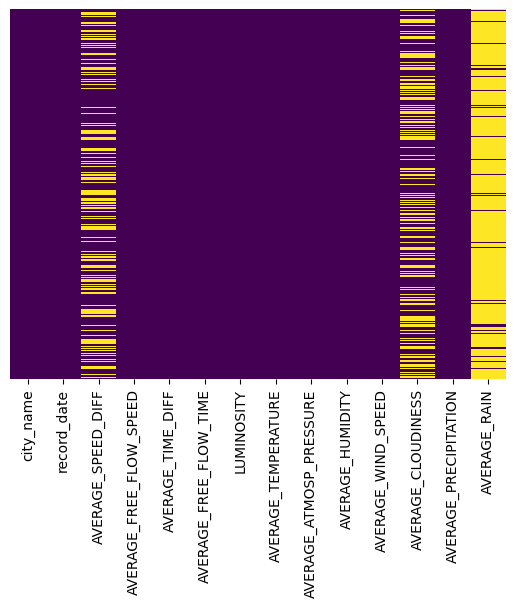

In [7]:
sns.heatmap(training.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [8]:
training.isnull().sum()

city_name                     0
record_date                   0
AVERAGE_SPEED_DIFF         2200
AVERAGE_FREE_FLOW_SPEED       0
AVERAGE_TIME_DIFF             0
AVERAGE_FREE_FLOW_TIME        0
LUMINOSITY                    0
AVERAGE_TEMPERATURE           0
AVERAGE_ATMOSP_PRESSURE       0
AVERAGE_HUMIDITY              0
AVERAGE_WIND_SPEED            0
AVERAGE_CLOUDINESS         2682
AVERAGE_PRECIPITATION         0
AVERAGE_RAIN               6249
dtype: int64

In [9]:
training.nunique()

city_name                     1
record_date                6812
AVERAGE_SPEED_DIFF            4
AVERAGE_FREE_FLOW_SPEED     225
AVERAGE_TIME_DIFF          1151
AVERAGE_FREE_FLOW_TIME      442
LUMINOSITY                    3
AVERAGE_TEMPERATURE          38
AVERAGE_ATMOSP_PRESSURE      43
AVERAGE_HUMIDITY             77
AVERAGE_WIND_SPEED           15
AVERAGE_CLOUDINESS            9
AVERAGE_PRECIPITATION         1
AVERAGE_RAIN                 13
dtype: int64

# Analise Info Dataset

In [10]:
numeric_cols = training.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols


['AVERAGE_FREE_FLOW_SPEED',
 'AVERAGE_TIME_DIFF',
 'AVERAGE_FREE_FLOW_TIME',
 'AVERAGE_TEMPERATURE',
 'AVERAGE_ATMOSP_PRESSURE',
 'AVERAGE_HUMIDITY',
 'AVERAGE_WIND_SPEED',
 'AVERAGE_PRECIPITATION']

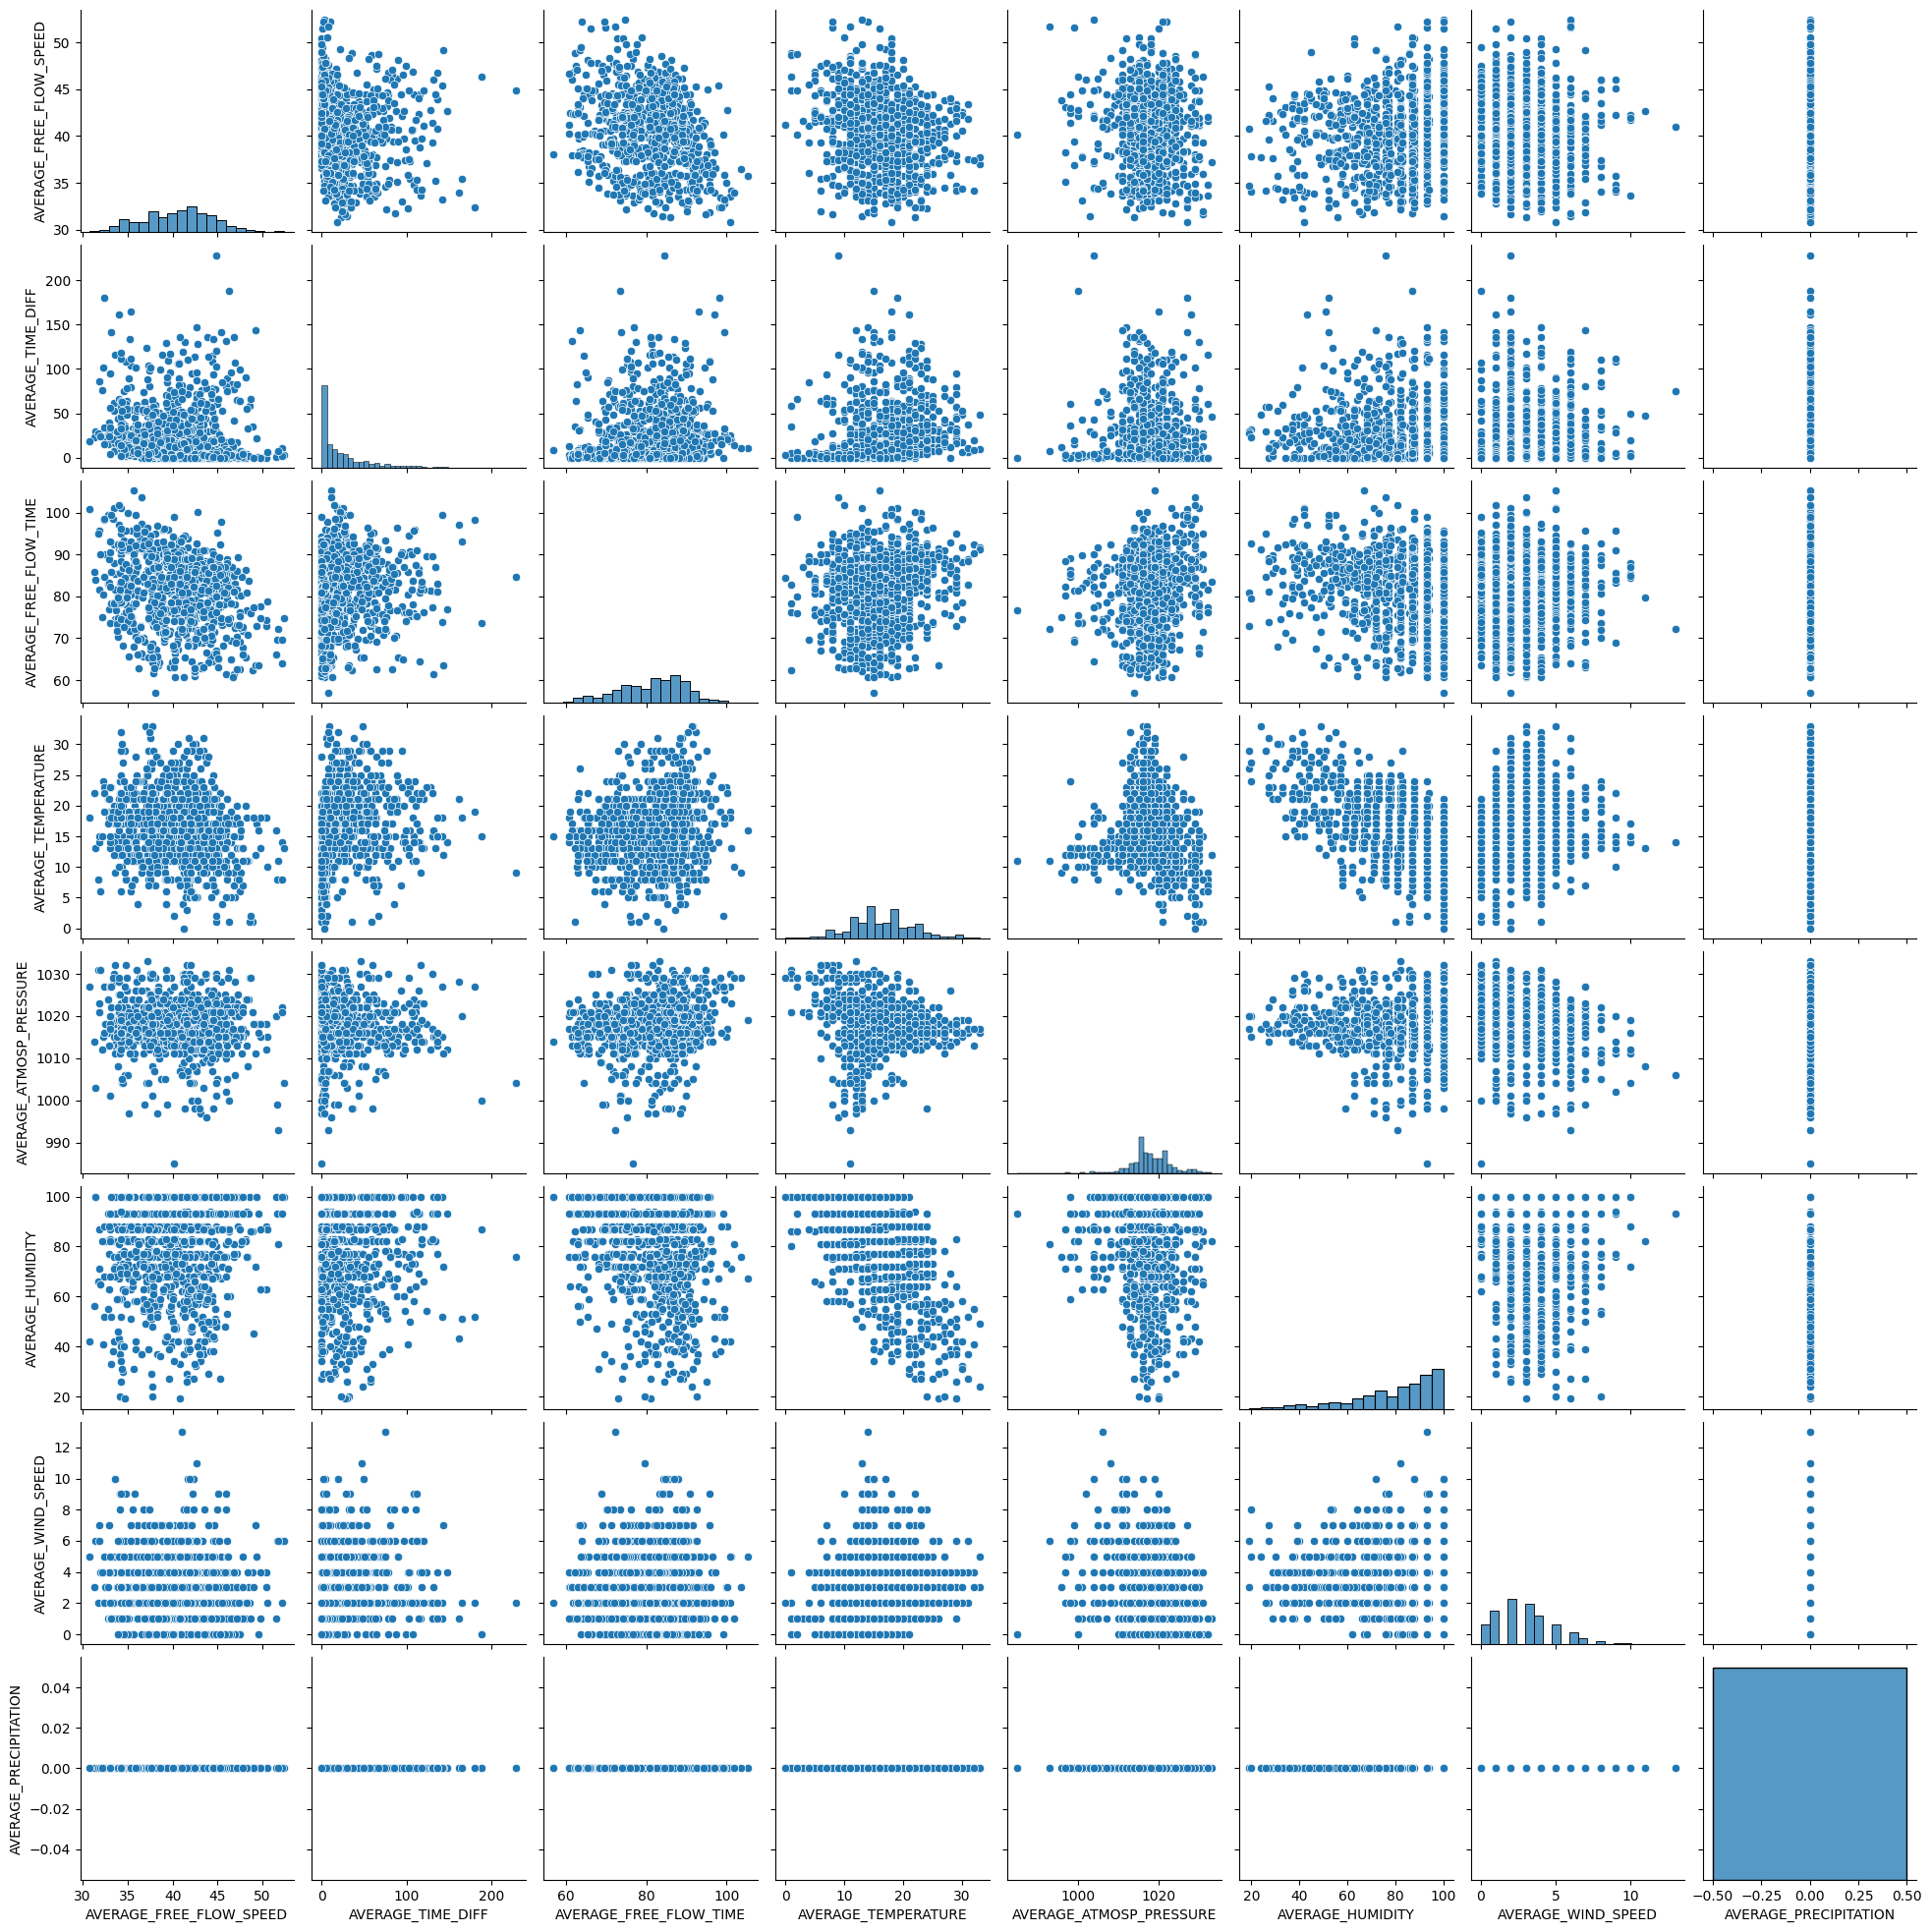

In [11]:
sample = training[numeric_cols].dropna().sample(n=1000, random_state=42)

sns.pairplot(sample)
plt.savefig("Pairplot1.png", dpi=300, bbox_inches='tight')
plt.show()



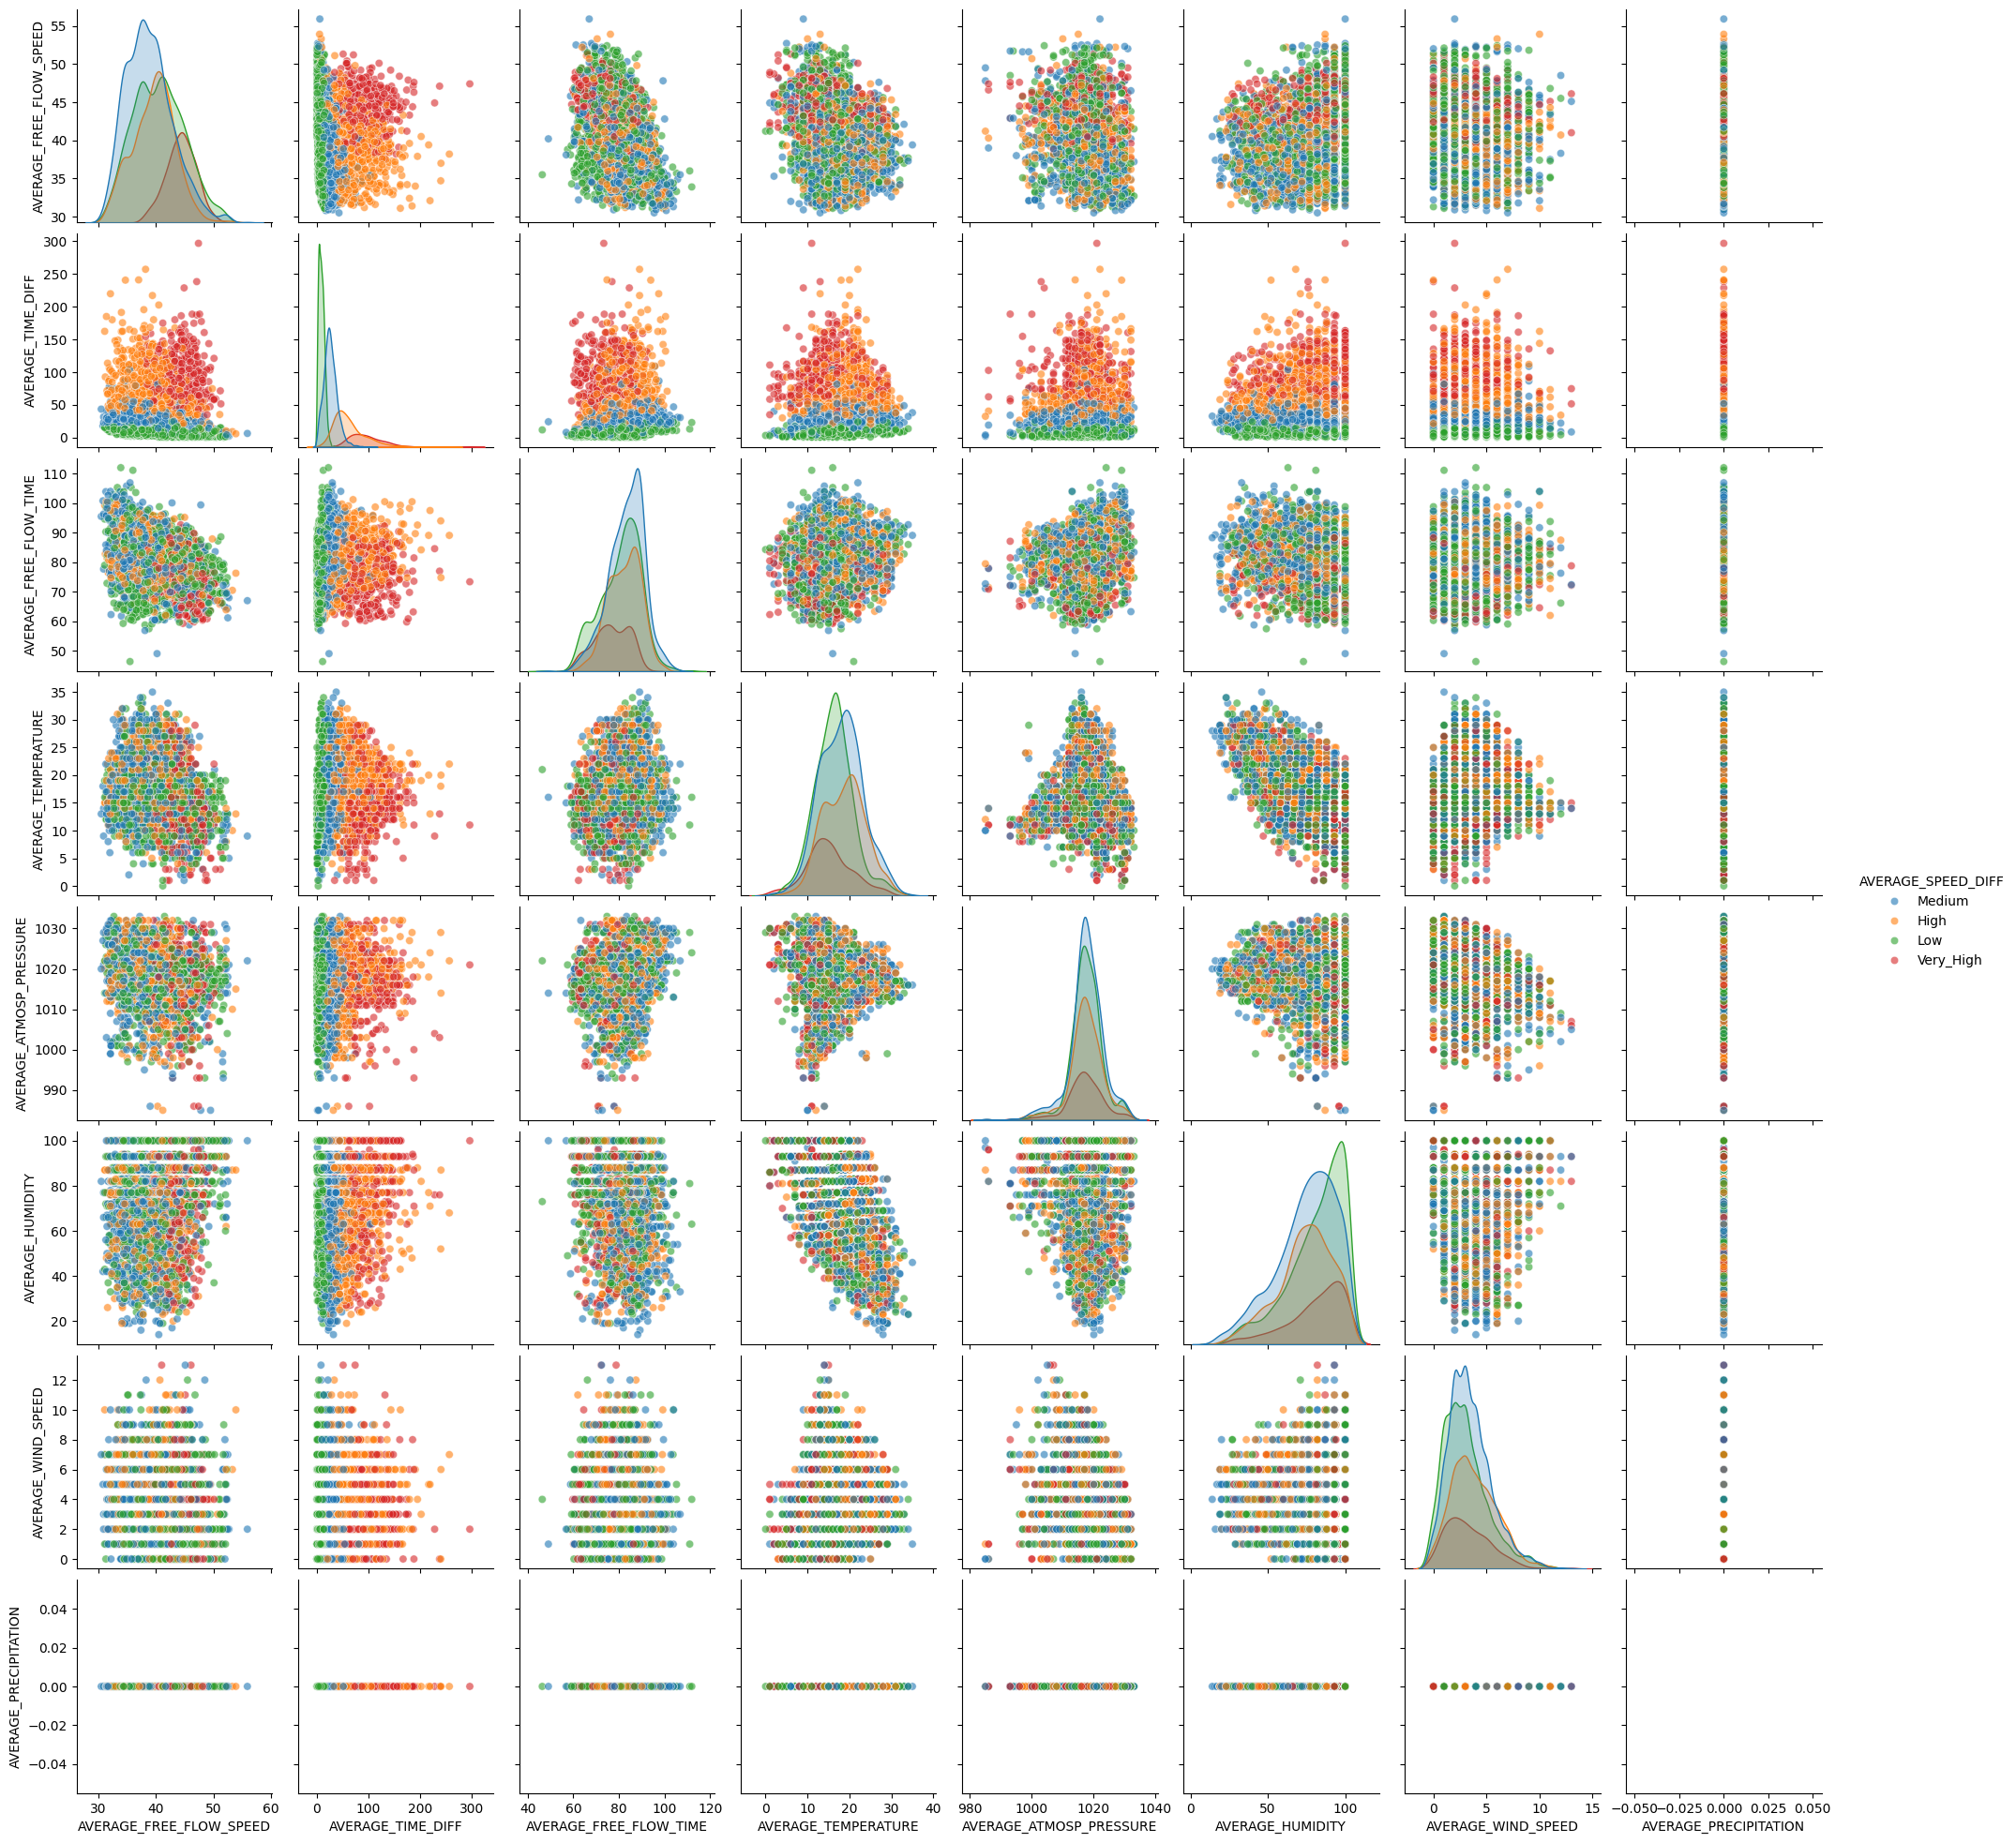

In [12]:
sample2 = training[numeric_cols + ['AVERAGE_SPEED_DIFF']].dropna()

sample2['AVERAGE_SPEED_DIFF'] = sample2['AVERAGE_SPEED_DIFF'].astype(str)

sns.pairplot(sample2, hue='AVERAGE_SPEED_DIFF', plot_kws={'alpha':0.6})
plt.savefig("Pairplot2.png", dpi=300, bbox_inches='tight')
plt.show()


In [13]:
corr_matrix = training[numeric_cols].corr()
corr_matrix


,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_PRECIPITATION
AVERAGE_FREE_FLOW_SPEED,1.000000,-0.083653,-0.219890,-0.192325,-0.093648,0.191598,-0.092909,NaN
AVERAGE_TIME_DIFF,-0.083653,1.000000,0.055194,0.205935,0.006243,-0.173598,0.169855,NaN
AVERAGE_FREE_FLOW_TIME,-0.219890,0.055194,1.000000,0.190404,0.126699,-0.128376,-0.025516,NaN
AVERAGE_TEMPERATURE,-0.192325,0.205935,0.190404,1.000000,-0.104469,-0.512383,0.131784,NaN
AVERAGE_ATMOSP_PRESSURE,-0.093648,0.006243,0.126699,-0.104469,1.000000,-0.067071,-0.162612,NaN
AVERAGE_HUMIDITY,0.191598,-0.173598,-0.128376,-0.512383,-0.067071,1.000000,-0.248708,NaN
AVERAGE_WIND_SPEED,-0.092909,0.169855,-0.025516,0.131784,-0.162612,-0.248708,1.000000,NaN
AVERAGE_PRECIPITATION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


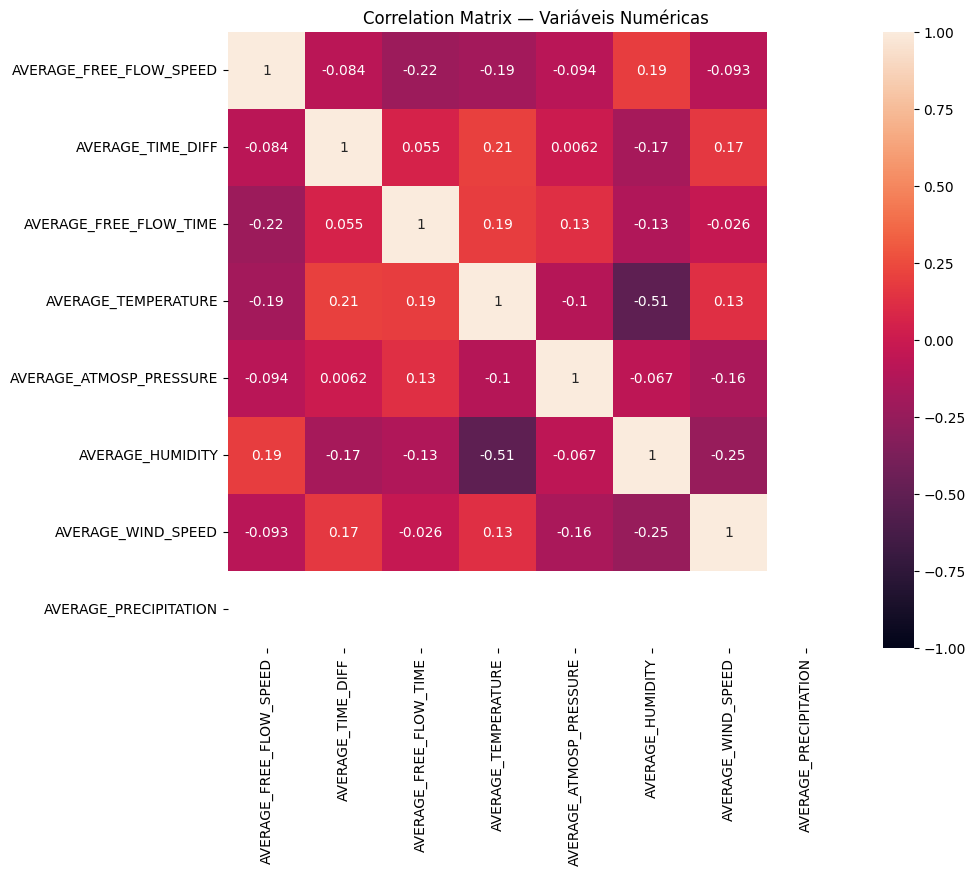

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, square=True, annot=True)
plt.title("Correlation Matrix — Variáveis Numéricas")
plt.savefig("Correlation.png", dpi=300, bbox_inches='tight')
plt.show()

